# Retailer Quality Analysis
Instacart-inspired fulfillment quality and retailer performance analysis.


In [57]:
import pandas as pd

base = r"C:\Users\cutes\OneDrive\Desktop\GitHub projects"

orders = pd.read_csv(f"{base}\orders.csv",
                     parse_dates=["order_date", "promised_delivery_time", "actual_delivery_time"])
orders.head()





,order_id,retailer_id,order_date,promised_delivery_time,actual_delivery_time,status,order_value,delivery_variance_min,delivery_outcome
0,O001,R001,2026-09-01,2026-09-02 10:00:00,2026-09-02 09:45:00,completed,$45.99,-15.0,On time
1,O002,R001,2026-09-01,2026-09-02 11:00:00,2026-09-02 12:10:00,completed,$32.50,70.0,Late
2,O003,R001,2026-09-03,2026-09-04 09:00:00,NaT,cancelled,$0.00,NaN,Cancelled
3,O004,R001,2026-09-04,2026-09-05 10:00:00,2026-09-05 10:05:00,completed,$27.80,5.0,Late
4,O005,R001,2026-09-05,2026-09-06 12:00:00,2026-09-06 11:50:00,completed,$63.40,-10.0,On time


## Create Fulfillment Flags


In [58]:
orders["is_cancelled"] = (orders["status"] == "cancelled").astype(int)
orders["is_rescheduled"] = (orders["status"] == "rescheduled").astype(int)
orders["is_completed"] = (orders["status"] == "completed").astype(int)

orders["is_on_time"] = (
    (orders["status"] == "completed") &
    (orders["actual_delivery_time"] <= orders["promised_delivery_time"])
).astype(int)

orders.head()


,order_id,retailer_id,order_date,promised_delivery_time,actual_delivery_time,status,order_value,delivery_variance_min,delivery_outcome,is_cancelled,is_rescheduled,is_completed,is_on_time
0,O001,R001,2026-09-01,2026-09-02 10:00:00,2026-09-02 09:45:00,completed,$45.99,-15.0,On time,0,0,1,1
1,O002,R001,2026-09-01,2026-09-02 11:00:00,2026-09-02 12:10:00,completed,$32.50,70.0,Late,0,0,1,0
2,O003,R001,2026-09-03,2026-09-04 09:00:00,NaT,cancelled,$0.00,NaN,Cancelled,1,0,0,0
3,O004,R001,2026-09-04,2026-09-05 10:00:00,2026-09-05 10:05:00,completed,$27.80,5.0,Late,0,0,1,0
4,O005,R001,2026-09-05,2026-09-06 12:00:00,2026-09-06 11:50:00,completed,$63.40,-10.0,On time,0,0,1,1


## Aggregate Retailer Metrics


In [59]:
import pandas as pd

base = r"C:\Users\cutes\OneDrive\Desktop\GitHub projects"

# Load orders
orders = pd.read_csv(
    f"{base}\orders.csv",
    parse_dates=["order_date", "promised_delivery_time", "actual_delivery_time"]
)

# Fix order_value dtype
orders["order_value"] = pd.to_numeric(orders["order_value"], errors="coerce")

# Create indicator columns
orders["is_cancelled"] = (orders["status"] == "cancelled").astype(int)
orders["is_rescheduled"] = (orders["status"] == "rescheduled").astype(int)
orders["is_completed"] = (orders["status"] == "completed").astype(int)
orders["is_on_time"] = (orders["delivery_outcome"] == "on_time").astype(int)

# Aggregate retailer metrics
retailer_metrics = (
    orders
    .groupby("retailer_id")
    .agg(
        total_orders=("order_id", "count"),
        cancelled_orders=("is_cancelled", "sum"),
        rescheduled_orders=("is_rescheduled", "sum"),
        completed_orders=("is_completed", "sum"),
        on_time_orders=("is_on_time", "sum"),
        avg_order_value=("order_value", "mean")
    )
)

retailer_metrics




,total_orders,cancelled_orders,rescheduled_orders,completed_orders,on_time_orders,avg_order_value
retailer_id,,,,,,
R001,5,1,0,4,0,NaN
R002,5,1,0,4,0,NaN
R003,5,1,0,4,0,NaN
R004,5,1,0,4,0,NaN
R005,5,1,0,4,0,NaN
R006,5,1,0,4,0,NaN
R007,5,1,0,4,0,NaN
R008,5,1,0,4,0,NaN
R009,5,1,0,4,0,NaN


## Calculate KPI Rates


In [60]:
retailer_metrics["cancellation_rate"] = retailer_metrics["cancelled_orders"] / retailer_metrics["total_orders"]
retailer_metrics["reschedule_rate"] = retailer_metrics["rescheduled_orders"] / retailer_metrics["total_orders"]
retailer_metrics["on_time_rate"] = retailer_metrics["on_time_orders"] / retailer_metrics["completed_orders"]

retailer_metrics


,total_orders,cancelled_orders,rescheduled_orders,completed_orders,on_time_orders,avg_order_value,cancellation_rate,reschedule_rate,on_time_rate
retailer_id,,,,,,,,,
R001,5,1,0,4,0,NaN,0.2,0.0,0.0
R002,5,1,0,4,0,NaN,0.2,0.0,0.0
R003,5,1,0,4,0,NaN,0.2,0.0,0.0
R004,5,1,0,4,0,NaN,0.2,0.0,0.0
R005,5,1,0,4,0,NaN,0.2,0.0,0.0
R006,5,1,0,4,0,NaN,0.2,0.0,0.0
R007,5,1,0,4,0,NaN,0.2,0.0,0.0
R008,5,1,0,4,0,NaN,0.2,0.0,0.0
R009,5,1,0,4,0,NaN,0.2,0.0,0.0


## Join Retailer Attributes


In [61]:
base = "C:/Users/cutes/OneDrive/Desktop/GitHub projects"

retailers = pd.read_csv(
    f"{base}/retailers.csv",
    parse_dates=["launch_date"]
)

print(retailers.columns)
retailers.head()


Index(['retailer_id', 'retailer_name', 'region', 'tier', 'launch_date'], dtype='object')


,retailer_id,retailer_name,region,tier,launch_date
0,R001,FreshMart,Ontario,Gold,2024-01-15
1,R002,QuickGrocer,Ontario,Silver,2025-03-10
2,R003,DailyNeeds,Ontario,Bronze,2023-11-20
3,R004,UrbanBasket,Ontario,Gold,2024-05-02
4,R005,GreenLeaf Market,Ontario,Silver,2024-07-18


## Add Escalation Metrics


In [62]:
escalations = pd.read_csv(
    f"{base}/escalations.csv",
    parse_dates=["created_at", "resolved_at"]
)

print(escalations.columns)
escalations.head()

escalation_counts = (
    escalations
    .groupby("retailer_id")
    .agg(escalation_count=("escalation_id", "count"))
)

retailer_metrics = retailer_metrics.merge(escalation_counts, on="retailer_id", how="left").fillna({"escalation_count": 0})
retailer_metrics["escalation_rate"] = retailer_metrics["escalation_count"] / retailer_metrics["total_orders"]

retailer_metrics


Index(['escalation_id', 'retailer_id', 'created_at', 'resolved_at',
       'issue_type'],
      dtype='object')


,total_orders,cancelled_orders,rescheduled_orders,completed_orders,on_time_orders,avg_order_value,cancellation_rate,reschedule_rate,on_time_rate,escalation_count,escalation_rate
retailer_id,,,,,,,,,,,
R001,5,1,0,4,0,NaN,0.2,0.0,0.0,2,0.4
R002,5,1,0,4,0,NaN,0.2,0.0,0.0,1,0.2
R003,5,1,0,4,0,NaN,0.2,0.0,0.0,1,0.2
R004,5,1,0,4,0,NaN,0.2,0.0,0.0,2,0.4
R005,5,1,0,4,0,NaN,0.2,0.0,0.0,2,0.4
R006,5,1,0,4,0,NaN,0.2,0.0,0.0,2,0.4
R007,5,1,0,4,0,NaN,0.2,0.0,0.0,2,0.4
R008,5,1,0,4,0,NaN,0.2,0.0,0.0,2,0.4
R009,5,1,0,4,0,NaN,0.2,0.0,0.0,2,0.4


## Save Output


In [63]:
import os
os.makedirs("../outputs", exist_ok=True)



## Visualizing Retailer Performance

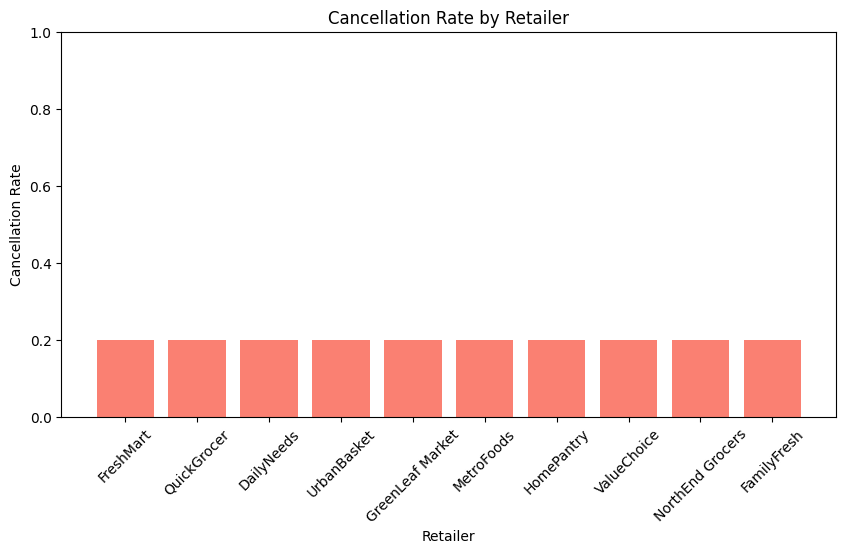

In [64]:

retailer_metrics = retailer_metrics.merge(
    retailers,
    on="retailer_id",
    how="left"
)

plt.figure(figsize=(10,5))
plt.bar(retailer_metrics["retailer_name"], retailer_metrics["cancellation_rate"], color="salmon")
plt.title("Cancellation Rate by Retailer")
plt.ylabel("Cancellation Rate")
plt.xlabel("Retailer")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()



## On-Time Delivery Rate by Retailer


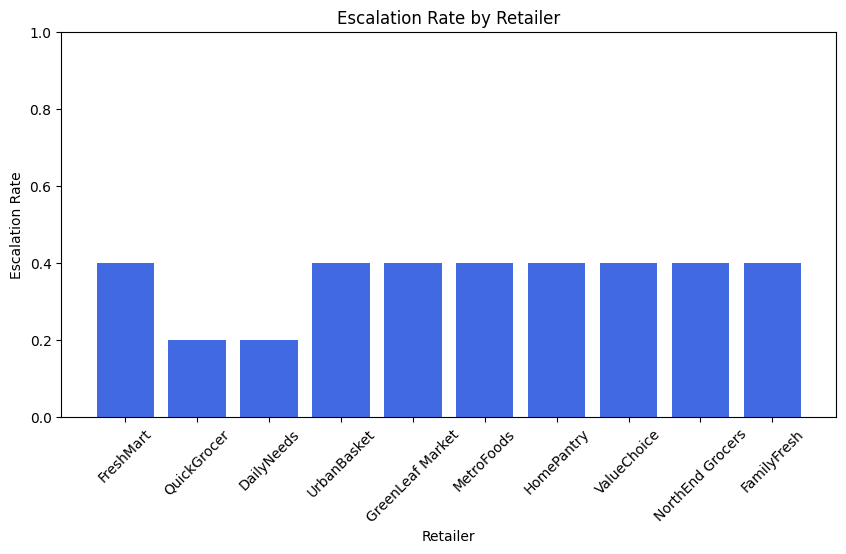

In [65]:
# Escalation Rate
plt.figure(figsize=(10,5))
plt.bar(retailer_metrics["retailer_name"], retailer_metrics["escalation_rate"], color="royalblue")
plt.title("Escalation Rate by Retailer")
plt.ylabel("Escalation Rate")
plt.xlabel("Retailer")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()




## Escalation Rate by Retailer


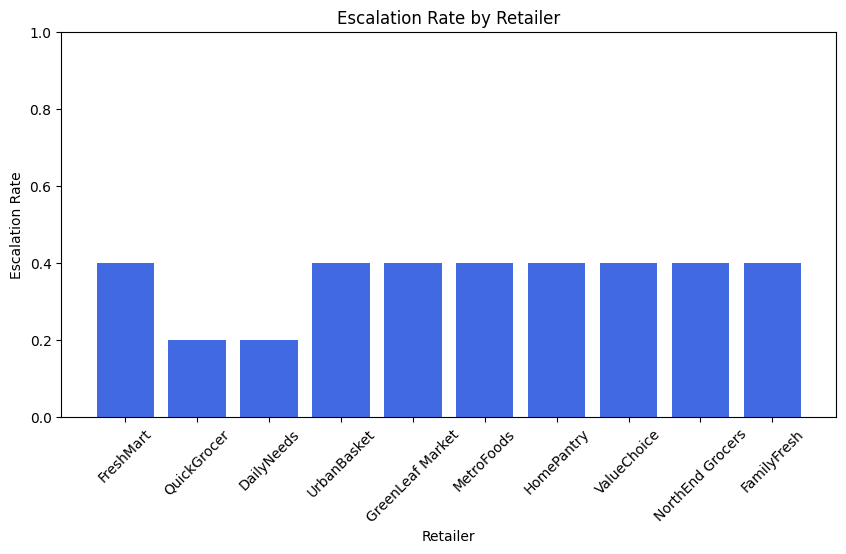

In [66]:
plt.figure(figsize=(10,5))
plt.bar(retailer_metrics["retailer_name"], retailer_metrics["escalation_rate"], color="royalblue")
plt.title("Escalation Rate by Retailer")
plt.ylabel("Escalation Rate")
plt.xlabel("Retailer")
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.show()
